In [34]:
# TensorFlow y tf.keras
import tensorflow as tf
from tensorflow import keras

# Librerias de ayuda
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.21.0


In [35]:
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [36]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [37]:
# len(train_images)
print(train_images.shape)
print(train_images[3])
# len(test_images)
print(test_images.shape)

(60000, 28, 28)
[[  0   0   0   0   0   0   0   0  33  96 175 156  64  14  54 137 204 194
  102   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0  73 186 177 183 175 188 232 255 223 219 194 179
  186 213 146   0   0   0   0   0   0   0]
 [  0   0   0   0   0  35 163 140 150 152 150 146 175 175 173 171 156 152
  148 129 156 140   0   0   0   0   0   0]
 [  0   0   0   0   0 150 142 140 152 160 156 146 142 127 135 133 140 140
  137 133 125 169  75   0   0   0   0   0]
 [  0   0   0   0   0  54 167 146 129 142 137 137 131 148 148 133 131 131
  131 125 140 140   0   0   0   0   0   0]
 [  0   0   0   0   0   0 110 188 133 146 152 133 125 127 119 129 133 119
  140 131 150  14   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 221 158 137 135 123 110 110 114 108 112 117
  127 142  77   0   0   0   0   0   0   0]
 [  0   0   0   0   0   4   0  25 158 137 125 119 119 110 117 117 110 119
  127 144   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 123 156 129 11

In [38]:
train_labels[:100]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4, 3, 0, 2, 4, 4, 5, 3, 6, 6, 0, 8, 5, 2, 1, 6, 6, 7, 9, 5,
       9, 2, 7, 3, 0, 3, 3, 3, 7, 2, 2, 6, 6, 8, 3, 3, 5, 0, 5, 5, 0, 2,
       0, 0, 4, 1, 3, 1, 6, 3, 1, 4, 4, 6, 1, 9, 1, 3, 5, 7, 9, 7, 1, 7,
       9, 9, 9, 3, 2, 9, 3, 6, 4, 1, 1, 8], dtype=uint8)

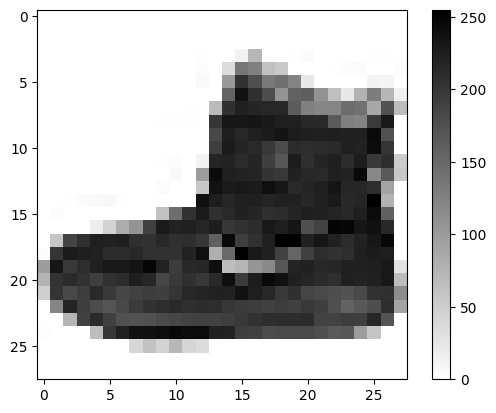

In [39]:
plt.figure()
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()


In [40]:
train_images = train_images / 255.0
print(train_images[3])

test_images = test_images / 255.0

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.12941176 0.37647059 0.68627451 0.61176471
  0.25098039 0.05490196 0.21176471 0.5372549  0.8        0.76078431
  0.4        0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.28627451 0.72941176 0.69411765 0.71764706 0.68627451 0.7372549
  0.90980392 1.         0.8745098  0.85882353 0.76078431 0.70196078
  0.72941176 0.83529412 0.57254902 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.1372549
  0.63921569 0.54901961 0.58823529 0.59607843 0.58823529 0.57254902
  0.68627451 0.68627451 0.67843137 0.67058824 0.61176471 0.59607843
  0.58039216 0.50588235 0.61176471 0.54901961 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.58823529
  0.55686275 0.54

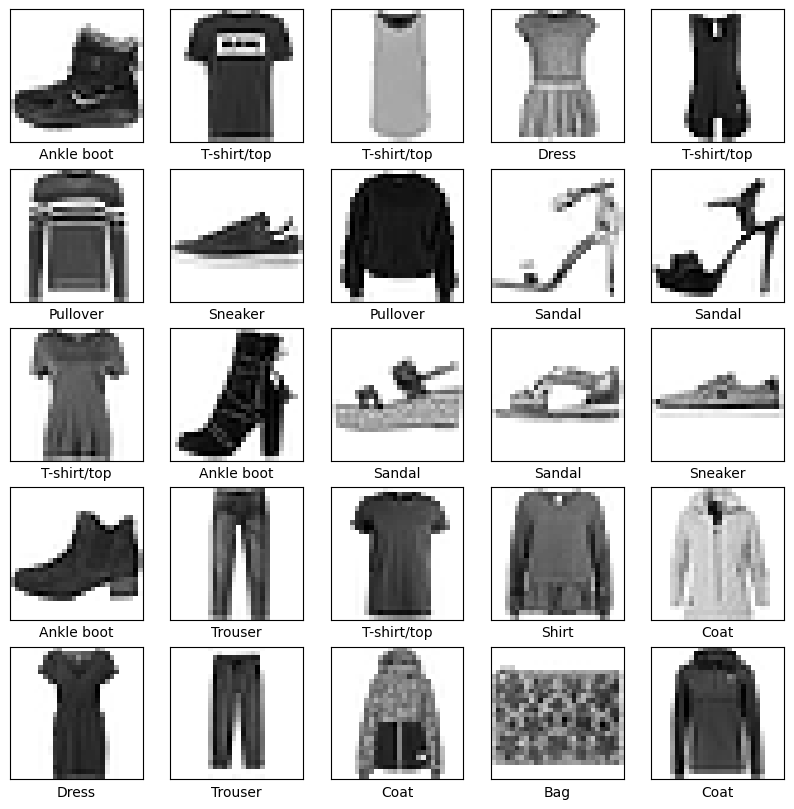

In [41]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

### **MODELO DE MACHINE LEARNING**

In [78]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # 784 caracteristicas (28*28)
    keras.layers.Dense(128, activation='relu'), # 128 neuronas
    keras.layers.Dense(10, activation='softmax') # 10 neuronas (10 clases)
])

C:\Users\Pc\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [79]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [80]:
model.fit(train_images, train_labels, validation_data=(test_images, test_labels), epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8256 - loss: 0.4957 - val_accuracy: 0.8510 - val_loss: 0.4218
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8643 - loss: 0.3760 - val_accuracy: 0.8520 - val_loss: 0.4082
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8765 - loss: 0.3364 - val_accuracy: 0.8699 - val_loss: 0.3641
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8837 - loss: 0.3133 - val_accuracy: 0.8701 - val_loss: 0.3672
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8914 - loss: 0.2959 - val_accuracy: 0.8771 - val_loss: 0.3447
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8965 - loss: 0.2793 - val_accuracy: 0.8707 - val_loss: 0.3462
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9019 - loss: 0.2672 - val_accuracy: 0.8841 - val_loss: 0.3272
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9039 - loss: 0.2563 - 

### **Evaluar Exactitud**

In [81]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.8708 - loss: 0.3787

Test accuracy: 0.8708000183105469


In [82]:
predictions = model.predict(test_images)
predictions[0]



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([5.6720040e-07, 9.3859651e-12, 1.0409643e-08, 1.0712899e-10,
       6.0845764e-08, 7.0369412e-04, 1.7160390e-06, 4.4295430e-02,
       2.4101006e-09, 9.5499855e-01], dtype=float32)

In [83]:
np.argmax(predictions[0])

np.int64(9)

In [84]:
test_labels[0]

np.uint8(9)

### ***Prueba de predicción***

Imagen 28x28 dibujada por miguelón


In [85]:
from PIL import Image

zapaton = Image.open("../data/zapaton2.jpg").convert("L")

zapaton = zapaton.resize((28, 28))
zapaton_array = np.array(zapaton) / 255.0
zapaton_array = zapaton_array.reshape(1, 28, 28)

prediccion_zapaton = model.predict(zapaton_array)
clase_predicha = np.argmax(prediccion_zapaton)
score = np.max(prediccion_zapaton)
print("La clase predicha para el zapatón es:", class_names[clase_predicha])
print("Score:", score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
La clase predicha para el zapatón es: Bag
Score: 0.99999976


In [ ]:
from tensorflow.keras.preprocessing import image
img_path = '../data/pantalon.jpg'
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')
img_array = image.img_to_array(img) / 255.0
img_array = img_array.reshape(1, 28, 28)

prediccion_pantalon = model.predict(img_array)
clase_predicha = np.argmax(prediccion_pantalon)
score = np.max(prediccion_pantalon)

print("La clase predicha es:", class_names[clase_predicha])
print("Score:", score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
La clase predicha es: Bag
Score: 0.99997866


*La verdad desconozco por qué imagen que le proporciono me dice que es una **bolsa*** 🤷‍♂️